In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df_adult = pd.read_csv('adult.csv')

# 2. "?" ko NaN se replace karein taake missing values detect hon
df_adult.replace('?', np.nan, inplace=True)

# 3. Check for duplicates and drop them
df_adult.drop_duplicates(inplace=True)

# 4. Fill categorical missing values with Mode
for col in ['workclass', 'occupation', 'native-country']:
    if col in df_adult.columns:
        df_adult[col] = df_adult[col].fillna(df_adult[col].mode()[0])

print("--- Adult Dataset Cleaned ---")
print(df_adult.isnull().sum())

--- Adult Dataset Cleaned ---
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [2]:
print("--- Age & Hours-per-week Summary ---")
print(df_adult[['age', 'hours-per-week']].describe())

print("\n--- Income Level Ratio ---")
print(df_adult['income'].value_counts(normalize=True) * 100)

print("\n--- Education vs Income Impact ---")
print(pd.crosstab(df_adult['education'], df_adult['income'], normalize='index') * 100)

--- Age & Hours-per-week Summary ---
                age  hours-per-week
count  48790.000000    48790.000000
mean      38.652798       40.425886
std       13.708493       12.392729
min       17.000000        1.000000
25%       28.000000       40.000000
50%       37.000000       40.000000
75%       48.000000       45.000000
max       90.000000       99.000000

--- Income Level Ratio ---
income
<=50K    76.058619
>50K     23.941381
Name: proportion, dtype: float64

--- Education vs Income Impact ---
income            <=50K       >50K
education                         
10th          93.736501   6.263499
11th          94.922737   5.077263
12th          92.671756   7.328244
1st-4th       96.734694   3.265306
5th-6th       94.674556   5.325444
7th-8th       93.501048   6.498952
9th           94.576720   5.423280
Assoc-acdm    74.203623  25.796377
Assoc-voc     74.660194  25.339806
Bachelors     58.679646  41.320354
Doctorate     27.441077  72.558923
HS-grad       84.140774  15.859226
Masters

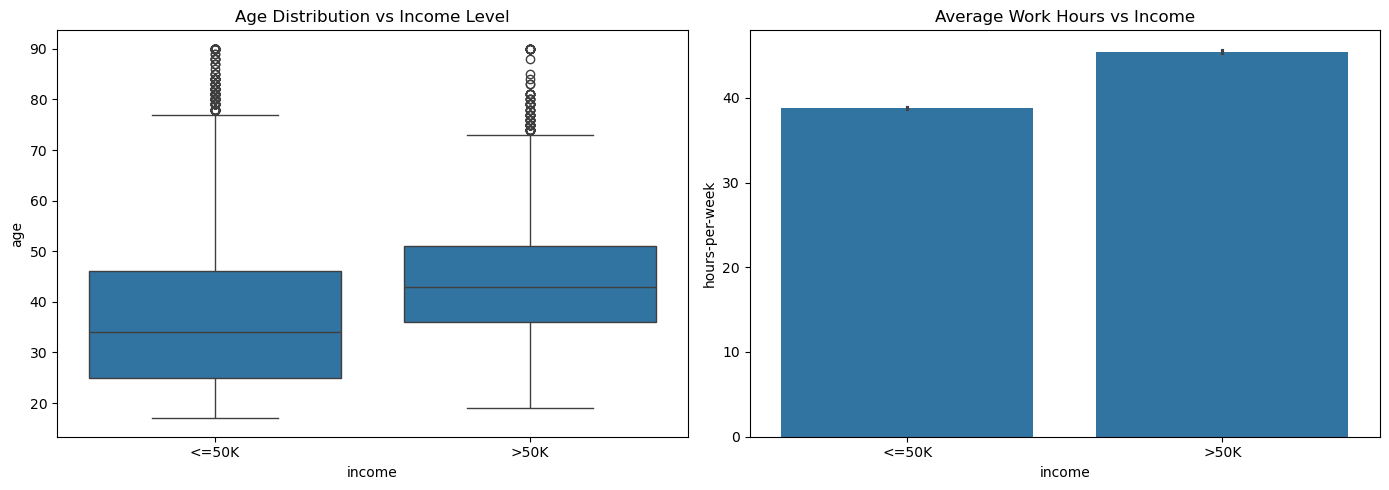

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Age distribution by Income
sns.boxplot(x='income', y='age', data=df_adult, ax=axes[0])
axes[0].set_title('Age Distribution vs Income Level')

# 2. Hours per week vs Income
sns.barplot(x='income', y='hours-per-week', data=df_adult, ax=axes[1])
axes[1].set_title('Average Work Hours vs Income')

plt.tight_layout()
plt.show()